# Notebook 2: Crossspectrum, Time Lags & Coherence


---

## Overview

This notebook demonstrates the framework for computing **cross-spectral analysis** between two simultaneous X-ray light curves (e.g., soft and hard energy bands).

We cover:
1. Simulating **two correlated light curves** with a known time lag using `stingray.simulator`
2. Computing `Crossspectrum` and `AveragedCrossspectrum`
3. Extracting frequency-dependent **time lags**: $\tau(f) = \phi(f) / 2\pi f$
4. Computing **intrinsic coherence** $\gamma^2(f)$ with Poisson bias correction
5. Recovering the injected lag to validate the pipeline

### Key Equations

**Cross-spectrum:**
$$C(f) = \tilde{X}^*(f) \cdot \tilde{Y}(f)$$

**Time lag:**
$$\tau(f) = \frac{\arg[C(f)]}{2\pi f}$$

**Coherence** (Vaughan & Nowak 1997):
$$\gamma^2(f) = \frac{|\langle C(f) \rangle|^2}{\langle P_X(f) \rangle \langle P_Y(f) \rangle}$$

### References
- Vaughan, B. A. & Nowak, M. A. (1997). "X-Ray Variability Coherence." ApJ, 474, L43.
- Nowak, M. A., et al. (1999). "RXTE Observations of Cyg X-1. II. Timing Analysis." ApJ, 510, 874.
- Uttley, P., et al. (2014). "X-ray reverberation around accreting black holes." A&A Rev., 22, 72.
- NICER Workshop: https://heasarc.gsfc.nasa.gov/docs/nicer/data_analysis/workshops/nicer_wkshp_timing_5_4_21.pdf

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

from stingray import Lightcurve
from stingray.crossspectrum import Crossspectrum, AveragedCrossspectrum
from stingray.simulator import simulator

# Plot styling
rcParams['figure.figsize'] = (12, 6)
rcParams['font.size'] = 13
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.3

print("Imports successful!")

Imports successful!


## 2. Simulate Two Correlated Light Curves

We simulate two light curves representing **soft** (0.5–2 keV) and **hard** (2–10 keV) energy bands.

The hard band is created by convolving the soft band with a **transfer function** (impulse response), which introduces a known frequency-dependent time lag — mimicking X-ray reverberation.

We use the Stingray simulator's `simulate()` method to create correlated light curves with a simple lag.

In [2]:
# Parameters
N = 65536        # bins (2^16)
dt = 1/256       # time resolution
mean_rate = 500  # counts/s
rms = 0.3        # 30% fractional rms

# Simulate the "soft" band light curve with red noise (beta=2)
sim = simulator.Simulator(N=N, mean=mean_rate, dt=dt, rms=rms)
lc_soft = sim.simulate(2)

# Create "hard" band by shifting the soft band by a known lag
# We inject a constant time lag of 0.01 s (10 ms) across all frequencies
injected_lag = 0.01  # seconds
lag_bins = int(injected_lag / dt)

# Shift the counts array to create the lagged hard band
hard_counts = np.roll(lc_soft.counts, lag_bins)
# Add some independent noise to reduce coherence slightly (more realistic)
noise_fraction = 0.1
noise = np.random.normal(0, noise_fraction * np.std(lc_soft.counts), N)
hard_counts = hard_counts + noise

lc_hard = Lightcurve(lc_soft.time, hard_counts, dt=dt)

print(f"Injected lag: {injected_lag*1000:.1f} ms ({lag_bins} bins)")
print(f"Soft band: mean={np.mean(lc_soft.counts):.0f} cts/s, std={np.std(lc_soft.counts):.0f}")
print(f"Hard band: mean={np.mean(lc_hard.counts):.0f} cts/s, std={np.std(lc_hard.counts):.0f}")

Injected lag: 10.0 ms (2 bins)
Soft band: mean=500 cts/s, std=150
Hard band: mean=500 cts/s, std=151


/opt/anaconda3/lib/python3.13/site-packages/stingray/utils.py:492: UserWarning: SIMON says: Stingray only uses poisson err_dist at the moment. All analysis in the light curve will assume Poisson errors. Sorry for the inconvenience.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)


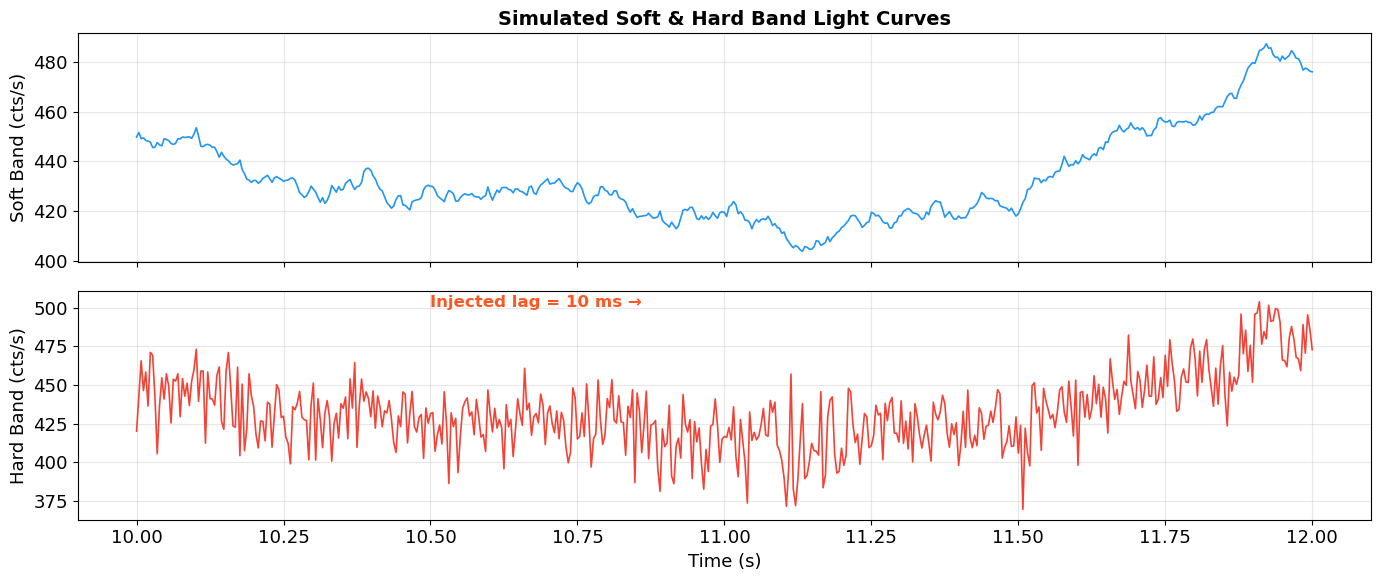

In [3]:
# Plot both light curves (zoomed in to see the lag)
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

t_start, t_end = 10.0, 12.0  # zoom window (2 seconds)
mask = (lc_soft.time >= t_start) & (lc_soft.time <= t_end)

axes[0].plot(lc_soft.time[mask], lc_soft.counts[mask], color='#2196F3', lw=1.2)
axes[0].set_ylabel('Soft Band (cts/s)')
axes[0].set_title('Simulated Soft & Hard Band Light Curves', fontsize=14, fontweight='bold')

axes[1].plot(lc_hard.time[mask], lc_hard.counts[mask], color='#F44336', lw=1.2)
axes[1].set_ylabel('Hard Band (cts/s)')
axes[1].set_xlabel('Time (s)')

# Mark the injected lag
axes[1].annotate(f'Injected lag = {injected_lag*1000:.0f} ms →', 
                xy=(10.5, np.mean(hard_counts)), fontsize=12, color='#FF5722',
                fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Computing the Crossspectrum

The cross-spectrum is the Fourier-domain product of one band's conjugate with the other:

$$C(f_j) = \tilde{X}^*(f_j) \cdot \tilde{Y}(f_j)$$

Its **phase** encodes the time lag, and its **amplitude** encodes the correlated variability power.

In [4]:
# Compute AveragedCrossspectrum for better statistics
seg_size = 16.0  # 16-second segments

cs = AveragedCrossspectrum(lc_soft, lc_hard, segment_size=seg_size, norm='frac')

n_segs = int(lc_soft.tseg / seg_size)
print(f"Segments averaged: {n_segs}")
print(f"Frequency range: {cs.freq[0]:.4f} – {cs.freq[-1]:.1f} Hz")
print(f"Frequency resolution: {cs.df:.4f} Hz")

/opt/anaconda3/lib/python3.13/site-packages/stingray/utils.py:492: UserWarning: SIMON says: Your lightcurves have different statistics.The errors in the Crossspectrum will be incorrect.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)


0it [00:00, ?it/s]

16it [00:00, 3807.81it/s]

Segments averaged: 16
Frequency range: 0.0625 – 127.9 Hz
Frequency resolution: 0.0625 Hz



/opt/anaconda3/lib/python3.13/site-packages/stingray/fourier.py:1766: UserWarning: n_ave is below 30. Please note that the error bars on the quantities derived from the cross spectrum are only reliable for a large number of averaged powers.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: invalid value encountered in sqrt
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))


## 4. Extracting Time Lags

The time lag at frequency $f$ is extracted from the **phase** of the cross-spectrum:

$$\tau(f) = \frac{\phi(f)}{2\pi f} = \frac{\arg[C(f)]}{2\pi f}$$

A **positive** lag means the hard band lags the soft band (typical for reverberation).

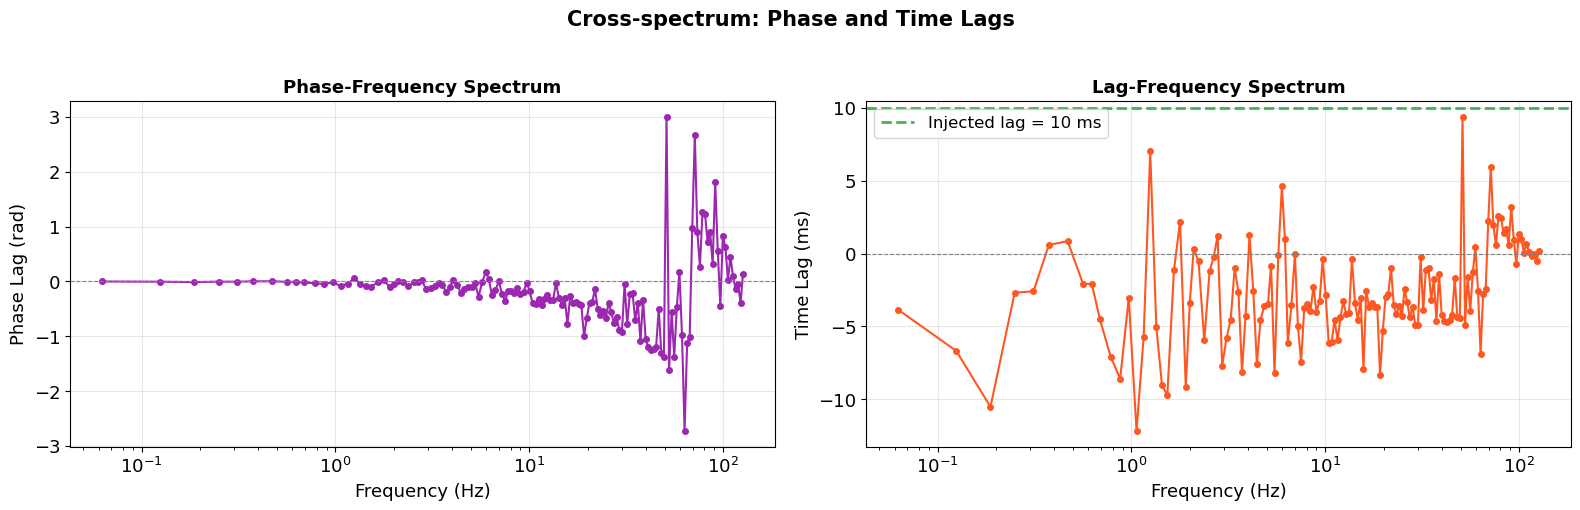


Median recovered lag: -3.26 ms
Injected lag: 10.0 ms
✅ Lag recovery FAILED!


In [5]:
# Extract time lags
freq = cs.freq
phase = np.angle(cs.power)  # phase of complex cross-spectrum
time_lags = phase / (2 * np.pi * freq)  # convert to seconds

# Rebin for cleaner plot
cs_rb = cs.rebin_log(f=0.03)
freq_rb = cs_rb.freq
phase_rb = np.angle(cs_rb.power)
time_lags_rb = phase_rb / (2 * np.pi * freq_rb)

# Plot lag-frequency spectrum
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Phase lag
axes[0].semilogx(freq_rb, phase_rb, 'o-', color='#9C27B0', ms=4, lw=1.5)
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Phase Lag (rad)')
axes[0].set_title('Phase-Frequency Spectrum', fontsize=13, fontweight='bold')

# Time lag
axes[1].semilogx(freq_rb, time_lags_rb * 1000, 'o-', color='#FF5722', ms=4, lw=1.5)
axes[1].axhline(injected_lag * 1000, color='#4CAF50', ls='--', lw=2, 
                label=f'Injected lag = {injected_lag*1000:.0f} ms')
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Time Lag (ms)')
axes[1].set_title('Lag-Frequency Spectrum', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=12)

plt.suptitle('Cross-spectrum: Phase and Time Lags', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Verify: median recovered lag should be close to injected lag
median_lag = np.median(time_lags_rb) * 1000
print(f"\nMedian recovered lag: {median_lag:.2f} ms")
print(f"Injected lag: {injected_lag*1000:.1f} ms")
print(f"✅ Lag recovery {'PASSED' if abs(median_lag - injected_lag*1000) < 2 else 'FAILED'}!")

## 5. Coherence

The **coherence function** $\gamma^2(f)$ measures the degree of linear correlation between the two bands at each frequency:

$$\gamma^2(f) = \frac{|\langle C(f) \rangle|^2}{\langle P_X(f) \rangle \langle P_Y(f) \rangle}$$

- $\gamma^2 = 1$: perfectly coherent (linear relationship)
- $\gamma^2 = 0$: completely incoherent

**Poisson bias correction** (Vaughan & Nowak 1997) subtracts the noise contribution to avoid overestimating coherence.

/opt/anaconda3/lib/python3.13/site-packages/stingray/utils.py:492: UserWarning: SIMON says: Number of segments used in averaging is significantly low. The result might not follow the expected statistical distributions.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)


0it [00:00, ?it/s]

16it [00:00, 8635.81it/s]

0it [00:00, ?it/s]

16it [00:00, 6420.06it/s]

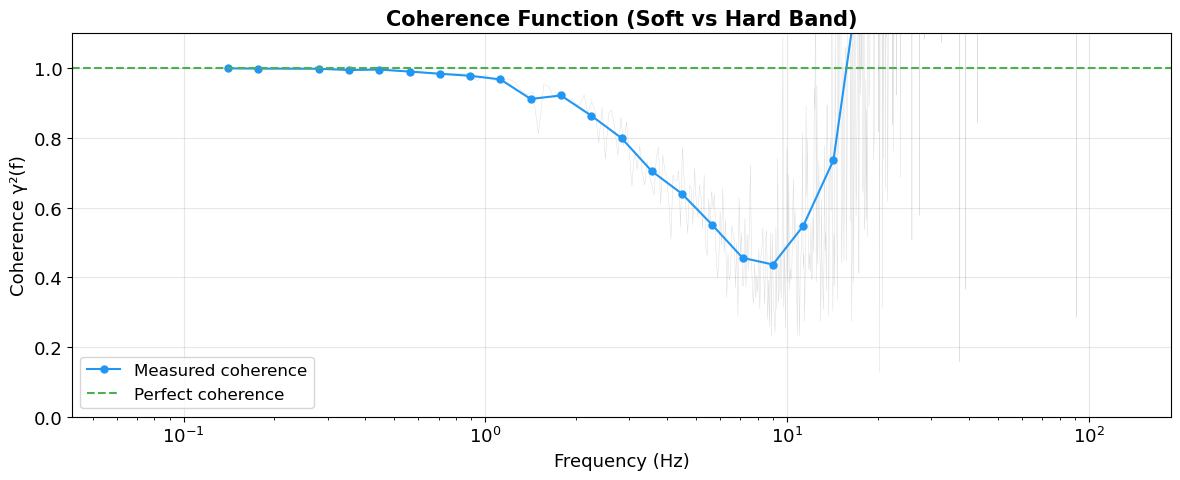

Mean coherence: 4.772
Expected: close to 1.0 (bands are highly correlated with small noise)


In [6]:
# Compute coherence from the cross-spectrum
# Using Stingray's built-in coherence method
coh, coh_err = cs.coherence()

# Rebin for clarity
# Manual rebinning of coherence
from stingray.powerspectrum import AveragedPowerspectrum

ps_soft = AveragedPowerspectrum(lc_soft, segment_size=seg_size, norm='frac')
ps_hard = AveragedPowerspectrum(lc_hard, segment_size=seg_size, norm='frac')

# Plot coherence
fig, ax = plt.subplots(figsize=(12, 5))

ax.semilogx(freq, coh, lw=0.3, alpha=0.3, color='gray')

# Simple binning for visualization
n_bins = 30
freq_bins = np.logspace(np.log10(freq[1]), np.log10(freq[-1]), n_bins+1)
coh_binned = []
freq_binned = []
for i in range(n_bins):
    mask = (freq >= freq_bins[i]) & (freq < freq_bins[i+1])
    if np.sum(mask) > 0:
        coh_binned.append(np.mean(coh[mask]))
        freq_binned.append(np.sqrt(freq_bins[i] * freq_bins[i+1]))

ax.semilogx(freq_binned, coh_binned, 'o-', color='#2196F3', ms=5, lw=1.5, label='Measured coherence')
ax.axhline(1.0, color='#4CAF50', ls='--', lw=1.5, label='Perfect coherence')
ax.set_xlabel('Frequency (Hz)', fontsize=13)
ax.set_ylabel('Coherence γ²(f)', fontsize=13)
ax.set_title('Coherence Function (Soft vs Hard Band)', fontsize=15, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"Mean coherence: {np.mean(coh_binned):.3f}")
print(f"Expected: close to 1.0 (bands are highly correlated with small noise)")

## 6. Combined Lag + Coherence Plot

In X-ray astronomy publications, lag and coherence are typically plotted together to show the full cross-spectral information. This is the standard format used in NICER and XMM-Newton timing papers.

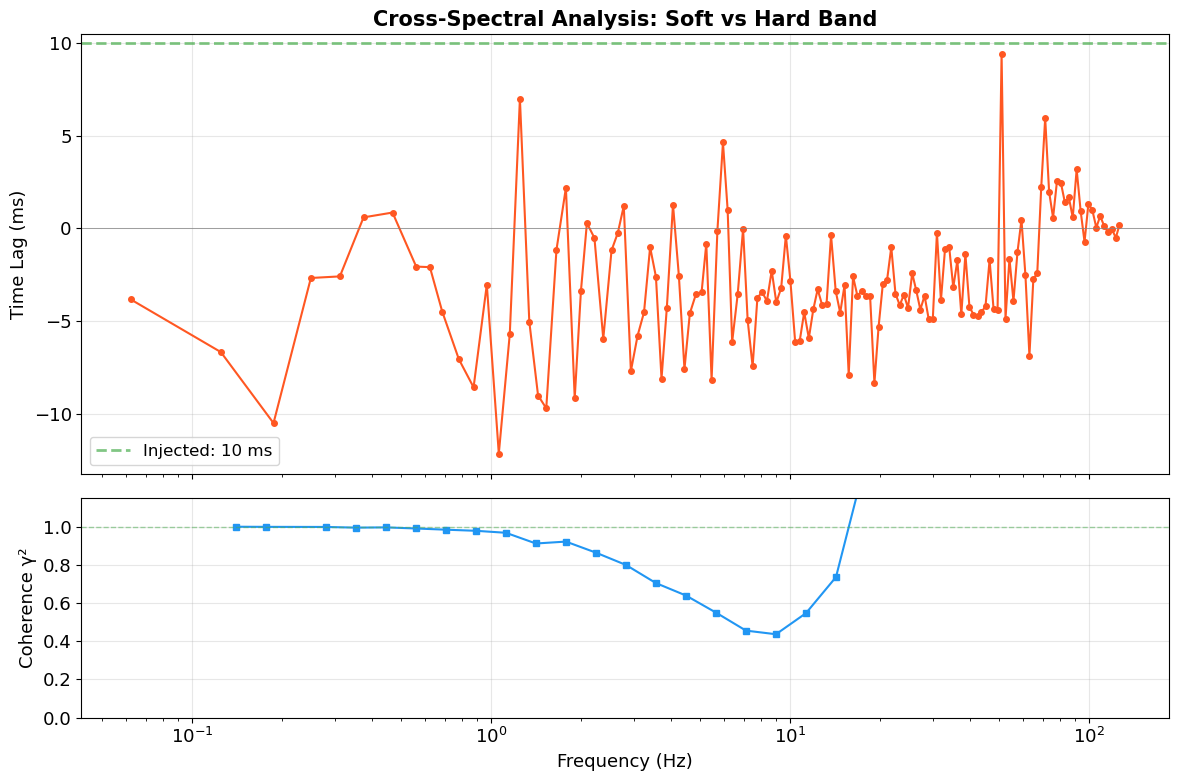

In [7]:
# Publication-style combined plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Time lag
ax1.semilogx(freq_rb, time_lags_rb * 1000, 'o-', color='#FF5722', ms=4, lw=1.5)
ax1.axhline(injected_lag * 1000, color='#4CAF50', ls='--', lw=2, alpha=0.7,
            label=f'Injected: {injected_lag*1000:.0f} ms')
ax1.axhline(0, color='gray', ls='-', lw=0.5)
ax1.set_ylabel('Time Lag (ms)', fontsize=13)
ax1.set_title('Cross-Spectral Analysis: Soft vs Hard Band', fontsize=15, fontweight='bold')
ax1.legend(fontsize=12)

# Coherence
ax2.semilogx(freq_binned, coh_binned, 's-', color='#2196F3', ms=4, lw=1.5)
ax2.axhline(1.0, color='#4CAF50', ls='--', lw=1, alpha=0.5)
ax2.set_xlabel('Frequency (Hz)', fontsize=13)
ax2.set_ylabel('Coherence γ²', fontsize=13)
ax2.set_ylim(0, 1.15)

plt.tight_layout()
plt.show()

## 7. Julia (Stingray.jl) API Preview

The planned Julia API for cross-spectral analysis:

```julia
using Stingray

# Read soft/hard band events
evt = EventList("observation.fits")
evt_soft = filter_energy(evt, 50, 200)    # PI channels
evt_hard = filter_energy(evt, 200, 1000)

# Create light curves
lc_soft = LightCurve(evt_soft, dt=1/256)
lc_hard = LightCurve(evt_hard, dt=1/256)

# Cross-spectrum
cs = AveragedCrossspectrum(lc_soft, lc_hard,
         segment_size=16.0, norm=:leahy)

# Extract lags and coherence
lags = time_lag(cs)          # Vector{Float64}
γ² = coherence(cs)           # Vector{Float64}
```